In [1]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [3]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [4]:
sae_bias_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "sae_bias_v3"

baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"


In [5]:
sae_bias_recalls, sae_bias_precisions = get_precisions_recalls(sae_bias_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)

In [6]:
sae_bias_recalls_auc = get_recalls_auc(sae_bias_path)
baseline_recalls_auc = get_recalls_auc(baseline_path)

In [7]:
np.array(sae_bias_recalls_auc).mean(), np.array(baseline_recalls_auc).mean()

(np.float64(0.8917321817360869), np.float64(0.8937074946193079))

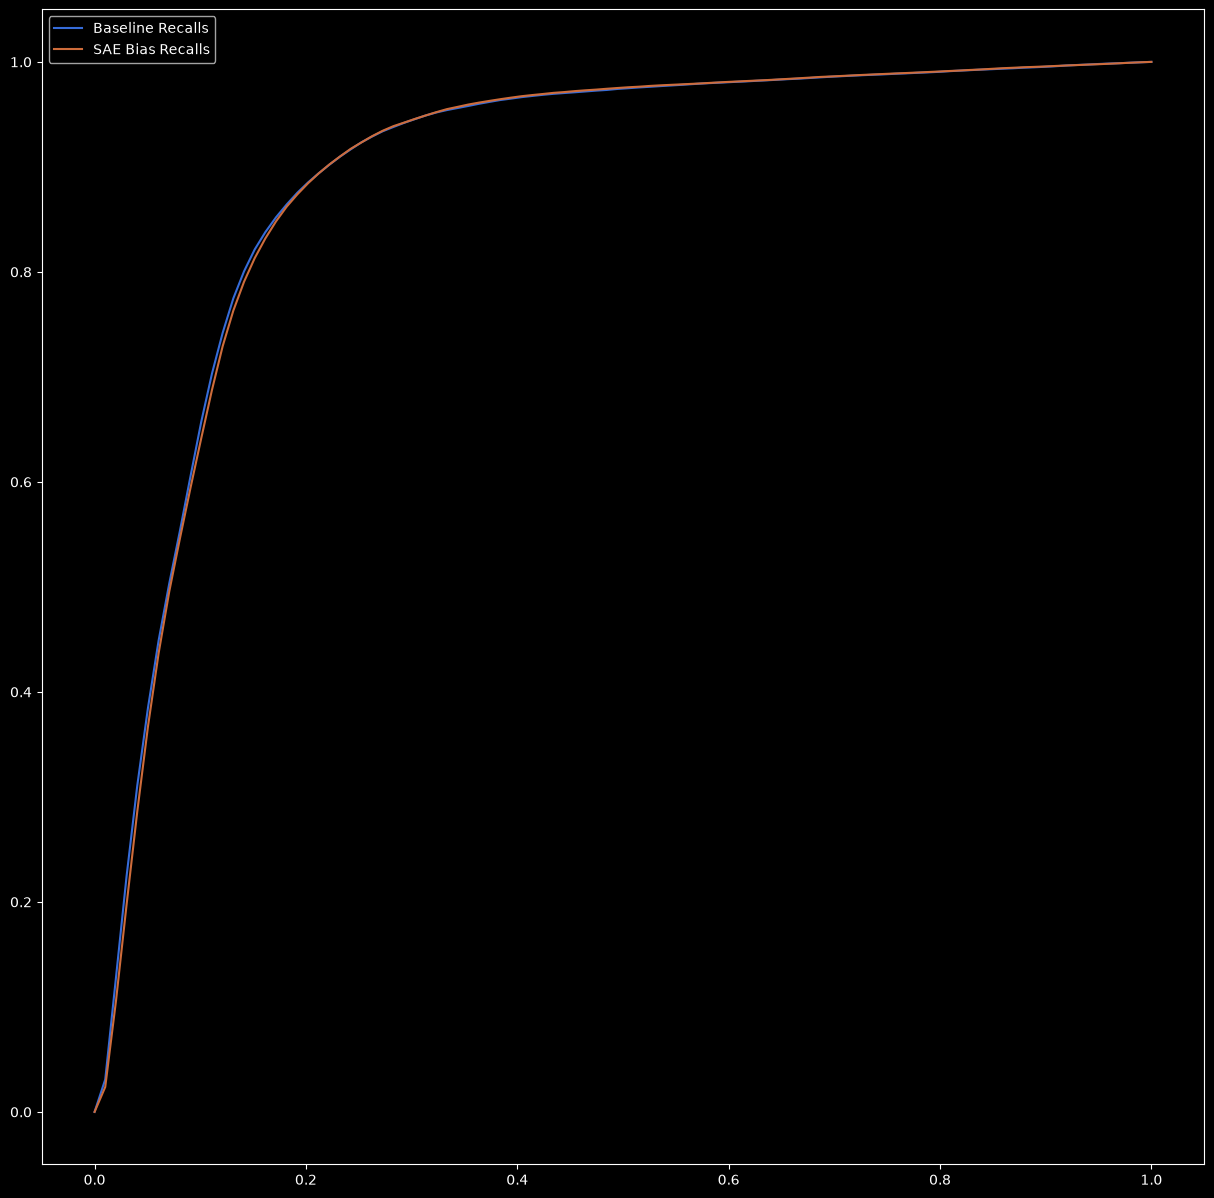

In [8]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(sae_bias_recalls).mean(axis=0),
         label="SAE Bias Recalls")

plt.legend()

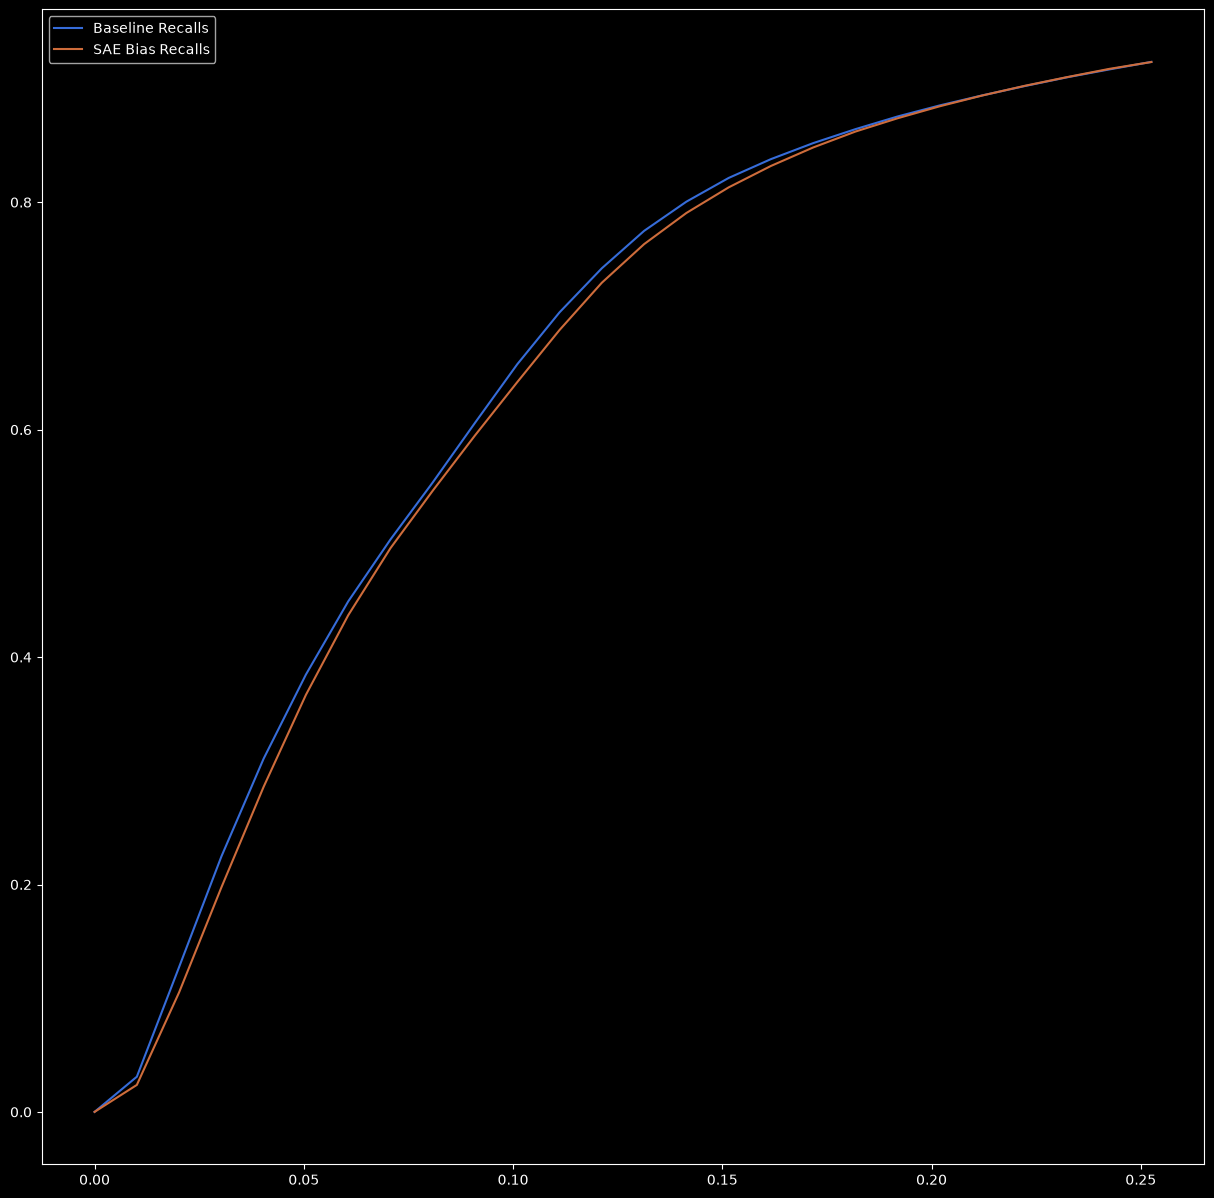

In [9]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26],
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(sae_bias_recalls).mean(axis=0)[:26],
         label="SAE Bias Recalls")

plt.legend()

In [10]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [11]:
delta_pct(np.array(sae_bias_recalls).mean(axis=0), np.array(baseline_recalls).mean(axis=0))

array([ 0.  , -0.72, -2.23, -2.72, -2.47, -1.78, -1.22, -0.77, -0.73,
       -1.11, -1.57, -1.55, -1.27, -1.17, -0.99, -0.83, -0.6 , -0.38,
       -0.21, -0.16, -0.08, -0.01,  0.02,  0.02,  0.05, -0.01,  0.03,
        0.05,  0.08,  0.02,  0.02,  0.01,  0.03,  0.09,  0.11,  0.13,
        0.11,  0.1 ,  0.08,  0.09,  0.09,  0.09,  0.08,  0.09,  0.09,
        0.11,  0.11,  0.1 ,  0.11,  0.09,  0.09,  0.07,  0.08,  0.07,
        0.06,  0.05,  0.03,  0.02,  0.02,  0.03,  0.03,  0.03,  0.02,
        0.02,  0.02,  0.03,  0.04,  0.04,  0.04,  0.03,  0.02,  0.02,
        0.03,  0.03,  0.04,  0.03,  0.03,  0.03,  0.03,  0.03,  0.02,
        0.01,  0.02,  0.01,  0.03,  0.04,  0.05,  0.04,  0.04,  0.03,
        0.03,  0.  , -0.01, -0.  , -0.02, -0.02, -0.01, -0.  ,  0.  ,
        0.  ])

In [12]:
sae_experiments: list[list] = load_experiment_metrics(sae_bias_path)

In [13]:
sae_s = []

for experiment in sae_experiments:
    sae_s += [metric.prediction for metric in experiment]

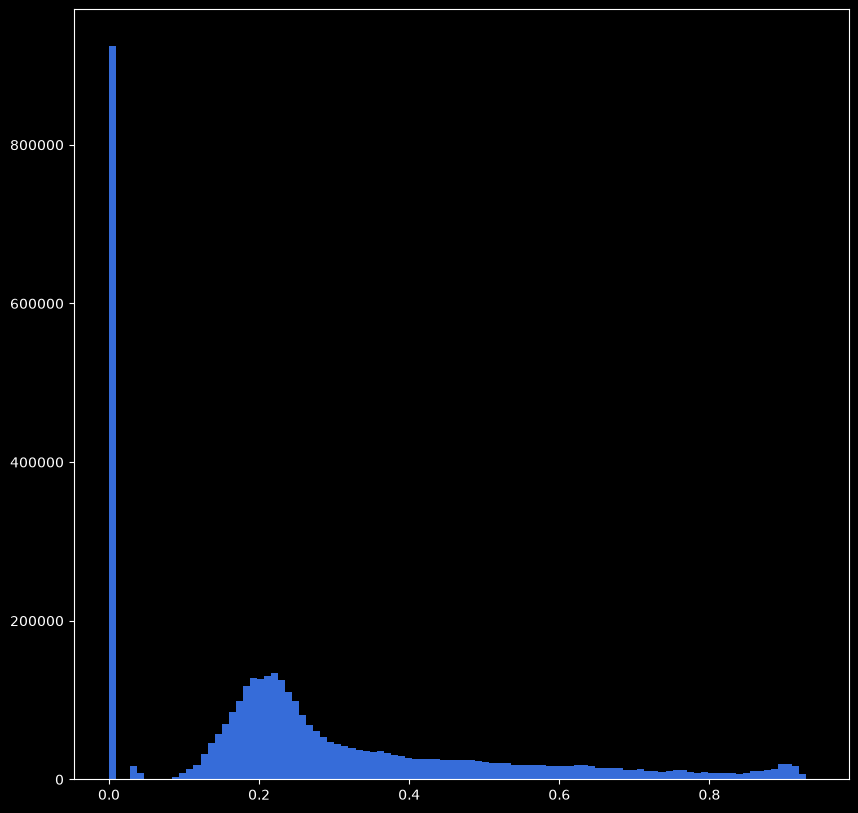

In [14]:
plt.figure(figsize=(10, 10))

plt.hist(sae_s, bins=100)
plt.show()